# 06 — Benchmark: Local vs Cloud Models

Same 5 RAG questions from notebook 05, sent to all 6 models via **LiteLLM** — a single
calling convention for local (Ollama) and cloud providers alike.

| Dimension | What we measure |
| --- | --- |
| **Performance** | Time-to-first-token (TTFT), tokens/sec |
| **Quality** | Factual accuracy on Contoso HR report (keyword-based, 0–5) |
| **Economics** | Cost per 1M tokens (cloud: official pricing; local: electricity only) |
| **Data Sovereignty** | Data residency, regulatory applicability, license, fine-tunability |

> **Why LiteLLM?** One function call — `litellm.completion()` — works identically for
> `ollama/mistral:7b` and `claude-sonnet-4-6`. No three native SDKs needed.

In [1]:
import os
import time
from pathlib import Path

import faiss
import litellm
import matplotlib.pyplot as plt
import numpy as np
import ollama
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from matplotlib.patches import Patch

from utils.helpers import check_model_available, check_ollama_running, chunk_text

os.environ.setdefault('LITELLM_LOG', 'ERROR')  # suppress verbose provider logs
litellm.drop_params = True  # silently ignore params unsupported by a provider

load_dotenv(find_dotenv())  # search up from CWD for .env

# ── Local models via Ollama ────────────────────────────────────────────────
LOCAL_MODELS: dict[str, dict] = {
    'mistral:7b': {
        'litellm_id': 'ollama/mistral:7b',
        'api_base': 'http://localhost:11434',
    },
    'qwen3.5:9b': {
        'litellm_id': 'ollama/qwen3.5:9b',
        'api_base': 'http://localhost:11434',
    },
    'gemma4:e4b': {
        'litellm_id': 'ollama/gemma4:e4b',
        'api_base': 'http://localhost:11434',
    },
}

# ── Cloud models via LiteLLM ───────────────────────────────────────────────
CLOUD_MODELS: dict[str, dict] = {
    'claude-sonnet-4-6': {
        'litellm_id': 'claude-sonnet-4-6',
        'api_base': None,
    },
    'gpt-5.4': {
        'litellm_id': 'gpt-5.4',
        'api_base': None,
    },
    'gemini-3.1-flash-lite': {
        'litellm_id': 'gemini/gemini-3.1-flash-lite',
        'api_base': None,
    },
}

if not check_ollama_running():
    raise RuntimeError('Ollama is not running. Start it with: ollama serve')

# ── Build active model list ────────────────────────────────────────────────
ACTIVE_MODELS: dict[str, dict] = {}

print('Local models:')
for _name, _cfg in LOCAL_MODELS.items():
    _ok = check_model_available(_name)
    _mark = '✓' if _ok else '✗'
    _note = '' if _ok else f'  (pull: ollama pull {_name})'
    print(f'  {_mark} {_name}{_note}')
    if _ok:
        ACTIVE_MODELS[_name] = _cfg

_KEY_MAP = {
    'claude-sonnet-4-6':     'ANTHROPIC_API_KEY',
    'gpt-5.4':               'OPENAI_API_KEY',
    'gemini-3.1-flash-lite': 'GEMINI_API_KEY',
}
print('\nCloud models:')
for _name, _cfg in CLOUD_MODELS.items():
    _env = _KEY_MAP[_name]
    _ok = bool(os.getenv(_env))
    _mark = '✓' if _ok else '✗'
    _note = '' if _ok else f'  ({_env} not set — skipping)'
    print(f'  {_mark} {_name}{_note}')
    if _ok:
        ACTIVE_MODELS[_name] = _cfg

print(f'\nActive models: {list(ACTIVE_MODELS.keys())}')

Local models:
  ✓ mistral:7b
  ✓ qwen3.5:9b
  ✓ gemma4:e4b

Cloud models:
  ✓ claude-sonnet-4-6
  ✓ gpt-5.4
  ✓ gemini-3.1-flash-lite

Active models: ['mistral:7b', 'qwen3.5:9b', 'gemma4:e4b', 'claude-sonnet-4-6', 'gpt-5.4', 'gemini-3.1-flash-lite']


## 1. RAG context

The same FAISS-based retrieval pipeline from notebook 05, rebuilt here so this notebook
is self-contained. RAG context is pre-computed **once per question** and shared across all
models — keeping the comparison fair.

In [2]:
EMBED_MODEL = 'qwen3-embedding:0.6b'
TOP_K = 5

REPORT = Path('data/contoso_report_q4_2024.md').read_text()
chunks = chunk_text(REPORT, chunk_size=512, overlap=64)

_embed = ollama.embed(model=EMBED_MODEL, input=chunks)
vectors = np.array(_embed.embeddings, dtype=np.float32)
faiss.normalize_L2(vectors)

dimension = vectors.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(vectors)

print(f'✓ {len(chunks)} chunks × {dimension} dims indexed in FAISS')

SYSTEM_PROMPT = (
    "You are a precise HR analyst. Answer the user's question using ONLY the "
    "context provided below. If the answer is not in the context, say "
    "'Not found in the document.'. Be concise and quote exact numbers "
    "when available.\n\nCONTEXT:\n{context}"
)


def retrieve(query: str, k: int = TOP_K) -> list[tuple[str, float]]:
    """Return top-k most relevant chunks for *query*."""
    q_vec = np.array(
        ollama.embed(model=EMBED_MODEL, input=[query]).embeddings,
        dtype=np.float32,
    )
    faiss.normalize_L2(q_vec)
    distances, indices = index.search(q_vec, k)
    return [
        (chunks[i], float(d))
        for i, d in zip(indices[0], distances[0], strict=True)
    ]

✓ 3 chunks × 1024 dims indexed in FAISS


In [3]:
TEST_QUESTIONS = [
    ('What is the total headcount of Contoso Corp as of Q4 2024?', '214'),
    ('What was the Q4 2024 attrition rate at Contoso?', '4.2'),
    ('Which department has the highest number of employees?', 'Engineering'),
    ('How many new hires are planned for Q1 2025?', '24'),
    ('What is the average base salary at Contoso Corp?', '81,300'),
]

# Pre-compute RAG context per question — reused across all models
contexts: list[str] = [
    '\n\n---\n\n'.join(chunk for chunk, _ in retrieve(q))
    for q, _ in TEST_QUESTIONS
]
print(f'✓ RAG context pre-computed for {len(TEST_QUESTIONS)} questions')


def benchmark_model(
    model_name: str,
    cfg: dict,
    question: str,
    context: str,
    timeout: int = 90,
) -> dict:
    """Run one question through one model; return timing + answer."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT.format(context=context)},
        {'role': 'user', 'content': question},
    ]
    kwargs: dict = {
        'model': cfg['litellm_id'],
        'messages': messages,
        'temperature': 0,
        'stream': True,
        'timeout': timeout,
    }
    if cfg['api_base']:
        kwargs['api_base'] = cfg['api_base']

    t0 = time.time()
    ttft: float | None = None
    full_text = ''

    try:
        for chunk in litellm.completion(**kwargs):
            delta = chunk.choices[0].delta.content or ''
            if ttft is None and delta:
                ttft = time.time() - t0
            full_text += delta
        elapsed = time.time() - t0
        words = len(full_text.split())
        return {
            'model': model_name,
            'question': question,
            'answer': full_text.strip(),
            'ttft_ms': round((ttft or elapsed) * 1000),
            'total_ms': round(elapsed * 1000),
            'tokens_per_sec': round(words / max(elapsed, 0.001) * 1.33),
            'error': None,
        }
    except Exception as exc:  # noqa: BLE001
        return {
            'model': model_name,
            'question': question,
            'answer': '',
            'ttft_ms': None,
            'total_ms': None,
            'tokens_per_sec': None,
            'error': str(exc)[:120],
        }

✓ RAG context pre-computed for 5 questions


## 2. Running the benchmark

Each active model answers all 5 questions. Results accumulate in a `pandas` DataFrame
for analysis and visualisation. Cloud models with missing API keys are skipped silently.

In [4]:
rows: list[dict] = []
total_runs = len(ACTIVE_MODELS) * len(TEST_QUESTIONS)
done = 0

for model_name, cfg in ACTIVE_MODELS.items():
    for (question, keyword), context in zip(
        TEST_QUESTIONS, contexts, strict=True
    ):
        result = benchmark_model(model_name, cfg, question, context)
        result['correct'] = (
            keyword.lower() in result['answer'].lower()
            if result['error'] is None
            else False
        )
        rows.append(result)
        done += 1
        status = '✓' if result['correct'] else (
            'error' if result['error'] else '✗'
        )
        print(
            f'[{done:2d}/{total_runs}] {model_name:<25}'
            f'  {status:<6}  {question[:48]}'
        )

df = pd.DataFrame(rows)
print(f'\nDone — {len(df)} results collected')

[ 1/30] mistral:7b                 ✓       What is the total headcount of Contoso Corp as o
[ 2/30] mistral:7b                 ✓       What was the Q4 2024 attrition rate at Contoso?
[ 3/30] mistral:7b                 ✓       Which department has the highest number of emplo
[ 4/30] mistral:7b                 ✓       How many new hires are planned for Q1 2025?
[ 5/30] mistral:7b                 ✓       What is the average base salary at Contoso Corp?
[ 6/30] qwen3.5:9b                 ✓       What is the total headcount of Contoso Corp as o
[ 7/30] qwen3.5:9b                 ✓       What was the Q4 2024 attrition rate at Contoso?
[ 8/30] qwen3.5:9b                 ✓       Which department has the highest number of emplo
[ 9/30] qwen3.5:9b                 ✓       How many new hires are planned for Q1 2025?
[10/30] qwen3.5:9b                 ✓       What is the average base salary at Contoso Corp?
[11/30] gemma4:e4b                 ✓       What is the total headcount of Contoso Corp as o


In [5]:
def _model_type(name: str) -> str:
    return 'Local' if name in LOCAL_MODELS else 'Cloud'


summary = (
    df.groupby('model')
    .agg(
        accuracy=('correct', 'mean'),
        avg_ttft_ms=('ttft_ms', 'mean'),
        avg_tps=('tokens_per_sec', 'mean'),
    )
    .reset_index()
)
summary.insert(1, 'type', summary['model'].apply(_model_type))
summary['accuracy'] = (summary['accuracy'] * 100).round(0).astype(int)
summary['avg_ttft_ms'] = summary['avg_ttft_ms'].round(0)
summary['avg_tps'] = summary['avg_tps'].round(1)
summary.columns = ['Model', 'Type', 'Accuracy (%)', 'Avg TTFT (ms)', 'Avg tok/s']

print(summary.sort_values('Accuracy (%)', ascending=False).to_string(index=False))

                Model  Type  Accuracy (%)  Avg TTFT (ms)  Avg tok/s
    claude-sonnet-4-6 Cloud           100         1460.0       12.0
gemini-3.1-flash-lite Cloud           100          766.0       23.2
           gemma4:e4b Local           100         9452.0        1.8
              gpt-5.4 Cloud           100          997.0       13.8
           mistral:7b Local           100         7667.0        5.2
           qwen3.5:9b Local           100        43633.0        0.0


## 3. Performance — TTFT and generation speed

Local models run on-device (no network overhead). Cloud models pay a round-trip penalty
on top of inference time. TTFT is measured from request start to first non-empty token.

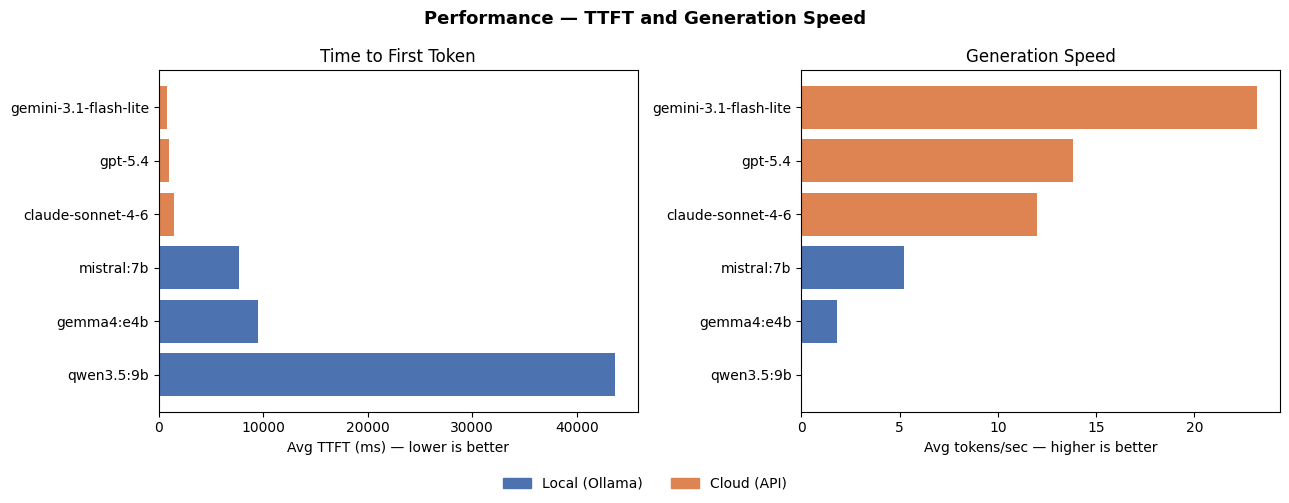

In [6]:
perf = (
    df[df['error'].isna()]
    .groupby('model')
    .agg(
        avg_ttft_ms=('ttft_ms', 'mean'),
        avg_tps=('tokens_per_sec', 'mean'),
    )
    .reset_index()
    .sort_values('avg_ttft_ms')
)

_legend_handles = [
    Patch(color='#4C72B0', label='Local (Ollama)'),
    Patch(color='#DD8452', label='Cloud (API)'),
]
_colors = [
    '#4C72B0' if m in LOCAL_MODELS else '#DD8452'
    for m in perf['model']
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Performance — TTFT and Generation Speed', fontsize=13, fontweight='bold')

ax1.barh(perf['model'], perf['avg_ttft_ms'], color=_colors)
ax1.set_xlabel('Avg TTFT (ms) — lower is better')
ax1.set_title('Time to First Token')
ax1.invert_yaxis()

ax2.barh(perf['model'], perf['avg_tps'], color=_colors)
ax2.set_xlabel('Avg tokens/sec — higher is better')
ax2.set_title('Generation Speed')
ax2.invert_yaxis()

fig.legend(handles=_legend_handles, loc='lower center', ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 4. Quality — factual accuracy

Each answer is checked against a ground-truth keyword from `contoso_report_q4_2024.md`.
A pass requires the exact value to appear in the response (e.g. `"214"`, `"4.2"`, `"Engineering"`).

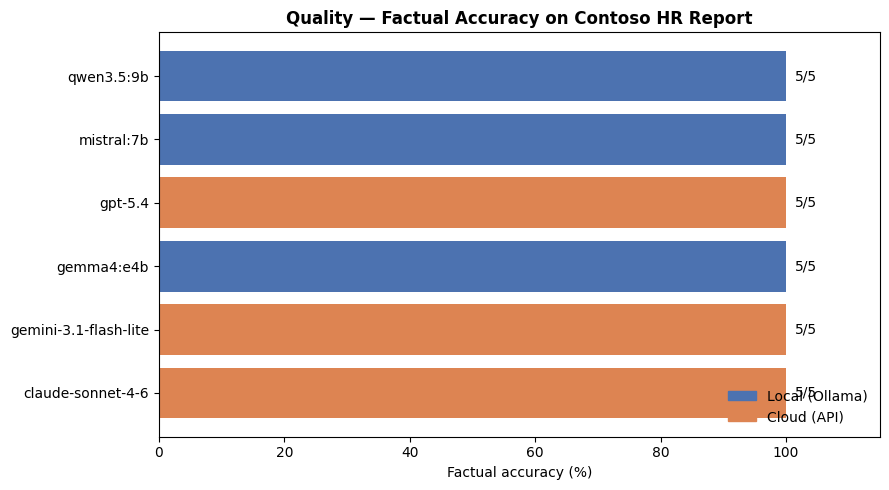

In [7]:
accuracy = (
    df.groupby('model')['correct']
    .agg(['sum', 'count'])
    .assign(pct=lambda x: x['sum'] / x['count'] * 100)
    .reset_index()
    .sort_values('pct', ascending=True)
)

_bar_colors = [
    '#4C72B0' if m in LOCAL_MODELS else '#DD8452'
    for m in accuracy['model']
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(accuracy['model'], accuracy['pct'], color=_bar_colors)

for bar, (_, row) in zip(bars, accuracy.iterrows(), strict=True):
    ax.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['sum'])}/{int(row['count'])}",
        va='center',
        fontsize=10,
    )

ax.set_xlabel('Factual accuracy (%)')
ax.set_title(
    'Quality — Factual Accuracy on Contoso HR Report',
    fontweight='bold',
)
ax.set_xlim(0, 115)
ax.legend(handles=_legend_handles, loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

## 5. Economics & Data Sovereignty

Static reference tables — values sourced from official provider pricing pages (May 2026)
and model licences.

**Local `Est. $/query`**: ~0.01 kWh/query × $0.20/kWh ≈ **$0.002** (electricity on Apple M-series).
No token cost — inference runs entirely on local hardware.

**Cloud `Est. $/query`**: computed as `(input_tokens × input_price + output_tokens × output_price) / 1_000_000`,
assuming ~3 500 input tokens (5 chunks × 512 words × 1.33 tok/word + system prompt + question)
and ~80 output tokens (concise answer).

In [8]:
economics = pd.DataFrame([
    {
        'Model': 'mistral:7b',
        'Type': 'Local',
        'Input $/1M tok': '$0',
        'Output $/1M tok': '$0',
        'Est. $/query': '~$0.002',
    },
    {
        'Model': 'qwen3.5:9b',
        'Type': 'Local',
        'Input $/1M tok': '$0',
        'Output $/1M tok': '$0',
        'Est. $/query': '~$0.002',
    },
    {
        'Model': 'gemma4:e4b',
        'Type': 'Local',
        'Input $/1M tok': '$0',
        'Output $/1M tok': '$0',
        'Est. $/query': '~$0.002',
    },
    {
        'Model': 'claude-sonnet-4-6',
        'Type': 'Cloud',
        'Input $/1M tok': '$3.00',
        'Output $/1M tok': '$15.00',
        'Est. $/query': '~$0.012',
    },
    {
        'Model': 'gpt-5.4',
        'Type': 'Cloud',
        'Input $/1M tok': '$2.50',
        'Output $/1M tok': '$15.00',
        'Est. $/query': '~$0.010',
    },
    {
        'Model': 'gemini-3.1-flash-lite',
        'Type': 'Cloud',
        'Input $/1M tok': '$0.25',
        'Output $/1M tok': '$1.50',
        'Est. $/query': '~$0.001',
    },
])

sovereignty = pd.DataFrame([
    {
        'Model': 'mistral:7b',
        'Data leaves machine': 'No',
        'Regulated sectors': 'Yes',
        'License': 'Apache 2.0',
        'Fine-tunable': 'Yes',
    },
    {
        'Model': 'qwen3.5:9b',
        'Data leaves machine': 'No',
        'Regulated sectors': 'Yes',
        'License': 'Apache 2.0',
        'Fine-tunable': 'Yes',
    },
    {
        'Model': 'gemma4:e4b',
        'Data leaves machine': 'No',
        'Regulated sectors': 'Yes',
        'License': 'Gemma ToU',
        'Fine-tunable': 'Yes',
    },
    {
        'Model': 'claude-sonnet-4-6',
        'Data leaves machine': 'Yes',
        'Regulated sectors': 'BAA required',
        'License': 'Proprietary',
        'Fine-tunable': 'No',
    },
    {
        'Model': 'gpt-5.4',
        'Data leaves machine': 'Yes',
        'Regulated sectors': 'BAA required',
        'License': 'Proprietary',
        'Fine-tunable': 'No',
    },
    {
        'Model': 'gemini-3.1-flash-lite',
        'Data leaves machine': 'Yes',
        'Regulated sectors': 'BAA required',
        'License': 'Proprietary',
        'Fine-tunable': 'No',
    },
])

sep = '-' * 68
print(f'Economics\n{sep}')
print(economics.to_string(index=False))
print(f'\nData Sovereignty\n{sep}')
print(sovereignty.to_string(index=False))

Economics
--------------------------------------------------------------------
                Model  Type Input $/1M tok Output $/1M tok Est. $/query
           mistral:7b Local             $0              $0      ~$0.002
           qwen3.5:9b Local             $0              $0      ~$0.002
           gemma4:e4b Local             $0              $0      ~$0.002
    claude-sonnet-4-6 Cloud          $3.00          $15.00      ~$0.012
              gpt-5.4 Cloud          $2.50          $15.00      ~$0.010
gemini-3.1-flash-lite Cloud          $0.25           $1.50      ~$0.001

Data Sovereignty
--------------------------------------------------------------------
                Model Data leaves machine Regulated sectors     License Fine-tunable
           mistral:7b                  No               Yes  Apache 2.0          Yes
           qwen3.5:9b                  No               Yes  Apache 2.0          Yes
           gemma4:e4b                  No               Yes   Gemma ToU    